# Do orderbook_delta messages include matched fills?

Our pipeline assumes they don't (and manually decrements on trades).
This notebook tests that assumption directly against raw bronze data.

**Test:** For each trade, check if a corresponding negative delta exists
at the consumed price/side within a tight time window.

- YES taker trade at price X → consumes NO resting order at (100-X)c
- NO taker trade at price X → consumes YES resting order at Xc

If fills ARE in deltas: most trades should have a matching negative delta.
If fills are NOT in deltas: no correlation.

In [1]:
import boto3
import gzip
import json
import pandas as pd
import numpy as np
from collections import defaultdict

s3 = boto3.client("s3")
BUCKET = "prediction-markets-data"
SOURCE = "kalshi_ws"

def load_bronze_channel(channel: str, date: str) -> list[dict]:
    """Load all bronze records for a channel+date. Prefers merged."""
    merged_key = f"bronze_merged/{SOURCE}/{channel}/date={date}/merged.jsonl.gz"
    try:
        resp = s3.get_object(Bucket=BUCKET, Key=merged_key)
        data = gzip.decompress(resp["Body"].read()).decode()
        records = [json.loads(line) for line in data.split("\n") if line.strip()]
        print(f"  {channel}: {len(records):,} records (merged)")
        return records
    except s3.exceptions.NoSuchKey:
        print(f"  {channel}: no merged file, trying raw...")
        y, m, d = date.split("-")
        prefix = f"bronze/{SOURCE}/{channel}/{y}/{m}/{d}/"
        paginator = s3.get_paginator("list_objects_v2")
        keys = []
        for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
            keys.extend(o["Key"] for o in page.get("Contents", []))
        keys = [k for k in keys if k.endswith(".jsonl.gz")]
        records = []
        for k in keys:
            resp = s3.get_object(Bucket=BUCKET, Key=k)
            raw = gzip.decompress(resp["Body"].read()).decode()
            for line in raw.split("\n"):
                if line.strip():
                    records.append(json.loads(line))
        print(f"  {channel}: {len(records):,} records ({len(keys)} raw files)")
        return records

DATE = "2026-04-22"
print(f"Loading bronze for {DATE}...")
delta_records = load_bronze_channel("orderbook_delta", DATE)
trade_records = load_bronze_channel("trade", DATE)
snap_records = load_bronze_channel("orderbook_snapshot", DATE)
print(f"\nTotal: {len(delta_records):,} deltas, {len(trade_records):,} trades, {len(snap_records):,} snapshots")

Loading bronze for 2026-04-22...
  orderbook_delta: 2,613,204 records (merged)
  trade: 472,097 records (merged)
  orderbook_snapshot: 6 records (merged)

Total: 2,613,204 deltas, 472,097 trades, 6 snapshots


## Step 1: Parse bronze into DataFrames

Extract the fields we need from each channel's raw JSON.

In [2]:
# Parse deltas
delta_rows = []
for rec in delta_records:
    frame = rec.get("frame", rec)  # handle both wrapped and unwrapped
    msg = frame.get("msg", {})
    t_receipt = rec.get("t_receipt", 0.0)
    price_str = msg.get("price_dollars", "0")
    price_cents = int(round(float(price_str) * 100))
    delta_val = int(round(float(msg.get("delta_fp", "0"))))
    delta_rows.append({
        "t_receipt": t_receipt,
        "ticker": msg.get("market_ticker", ""),
        "side": msg.get("side", ""),
        "price_cents": price_cents,
        "delta": delta_val,
        "seq": frame.get("seq"),
        "sid": frame.get("sid"),
        "t_exchange": msg.get("ts"),
    })

deltas = pd.DataFrame(delta_rows)
deltas = deltas[deltas["ticker"] != ""].copy()
print(f"Deltas: {len(deltas):,} rows")
print(f"  Positive (placements): {(deltas['delta'] > 0).sum():,}")
print(f"  Negative (removals):   {(deltas['delta'] < 0).sum():,}")
print(f"  Zero:                  {(deltas['delta'] == 0).sum():,}")
print(f"\nSample:")
deltas.head(3)

Deltas: 2,613,204 rows
  Positive (placements): 1,103,891
  Negative (removals):   1,427,988
  Zero:                  81,325

Sample:


,t_receipt,ticker,side,price_cents,delta,seq,sid,t_exchange
0,1.776819e+09,KXNBAGAME-26APR24LALHOU-LAL,no,74,-68,1139750,2,2026-04-22T00:52:11.67131Z
1,1.776819e+09,KXNBAGAME-26APR21PORSAS-POR,no,54,0,1139751,2,2026-04-22T00:52:11.695578Z
2,1.776819e+09,KXNBAGAME-26APR24SASPOR-POR,no,69,-11,1139752,2,2026-04-22T00:52:11.82376Z


In [3]:
# Parse trades
trade_rows = []
for rec in trade_records:
    frame = rec.get("frame", rec)
    msg = frame.get("msg", {})
    t_receipt = rec.get("t_receipt", 0.0)
    yes_price = msg.get("yes_price_dollars")
    if yes_price is None:
        continue
    yes_price_cents = int(round(float(str(yes_price)) * 100))
    fill_size = int(round(float(msg.get("count_fp", "0"))))
    taker_side = msg.get("taker_side", "")
    trade_rows.append({
        "t_receipt": t_receipt,
        "ticker": msg.get("market_ticker", ""),
        "taker_side": taker_side,
        "yes_price_cents": yes_price_cents,
        "fill_size": fill_size,
        # The consumed side: if YES taker, they ate NO orders at (100 - yes_price)
        # If NO taker, they ate YES orders at yes_price
        "consumed_side": "no" if taker_side == "yes" else "yes",
        "consumed_price": (100 - yes_price_cents) if taker_side == "yes" else yes_price_cents,
        "seq": frame.get("seq"),
        "sid": frame.get("sid"),
        "t_exchange": msg.get("ts"),
    })

trades = pd.DataFrame(trade_rows)
trades = trades[trades["ticker"] != ""].copy()
print(f"Trades: {len(trades):,} rows")
print(f"  YES taker: {(trades['taker_side'] == 'yes').sum():,}")
print(f"  NO taker:  {(trades['taker_side'] == 'no').sum():,}")
print(f"\nSample:")
trades.head(5)

Trades: 472,097 rows
  YES taker: 332,133
  NO taker:  139,964

Sample:


,t_receipt,ticker,taker_side,yes_price_cents,fill_size,consumed_side,consumed_price,seq,sid,t_exchange
0,1.776817e+09,KXNBATOTAL-26APR21PHIBOS-231,yes,27,60,no,73,101265,5,1776816844
1,1.776817e+09,KXNBAGAME-26APR21PHIBOS-BOS,yes,68,7,no,32,101266,5,1776816844
2,1.776817e+09,KXNBAGAME-26APR21PORSAS-POR,yes,30,78,no,70,101267,5,1776816844
3,1.776817e+09,KXNBAGAME-26APR21PORSAS-POR,yes,30,16,no,70,101268,5,1776816844
4,1.776817e+09,KXNBAGAME-26APR21PHIBOS-PHI,yes,33,142,no,67,101269,5,1776816844


## Step 2: Do trades and deltas share a sequence space?

Each WS subscription gets a `sid` (subscription ID) and messages within that 
subscription get incrementing `seq` numbers. If trades and deltas share the 
same `sid`, their `seq` numbers are directly comparable — a trade at seq=500 
and a delta at seq=501 are literally consecutive messages from the server.

If they're on different `sid`s, seq comparison is meaningless and we skip to 
the time-based test.

In [4]:
# Pick the most active ticker for focused analysis
TICKER = trades["ticker"].value_counts().index[0]
print(f"Most active ticker: {TICKER}")
print(f"  Trades: {len(trades[trades['ticker'] == TICKER]):,}")
print(f"  Deltas: {len(deltas[deltas['ticker'] == TICKER]):,}")

t_trades = trades[trades["ticker"] == TICKER].copy().sort_values("seq")
t_deltas = deltas[deltas["ticker"] == TICKER].copy().sort_values("seq")

# KEY CHECK: do trades and deltas share sids?
trade_sids = set(t_trades["sid"].unique())
delta_sids = set(t_deltas["sid"].unique())
shared_sids = trade_sids & delta_sids

print(f"\nTrade SIDs: {sorted(trade_sids)}")
print(f"Delta SIDs: {sorted(delta_sids)}")
print(f"Shared SIDs: {sorted(shared_sids)}")

if shared_sids:
    print(f"\n--> Trades and deltas SHARE sid(s) {shared_sids}.")
    print(f"    seq numbers are in the same space — seq-based test is valid.")
    SEQ_TEST_VALID = True
else:
    print(f"\n--> Trades and deltas are on DIFFERENT sids.")
    print(f"    seq numbers are NOT comparable — skipping seq-based test.")
    SEQ_TEST_VALID = False

# Build negative delta lookup for this ticker
neg_deltas = t_deltas[t_deltas["delta"] < 0]
print(f"\nNegative deltas for {TICKER}: {len(neg_deltas):,}")

Most active ticker: KXNBAGAME-26APR21HOULAL-LAL
  Trades: 66,224
  Deltas: 295,270

Trade SIDs: [np.int64(5)]
Delta SIDs: [np.int64(2)]
Shared SIDs: []

--> Trades and deltas are on DIFFERENT sids.
    seq numbers are NOT comparable — skipping seq-based test.

Negative deltas for KXNBAGAME-26APR21HOULAL-LAL: 171,469


In [5]:
# Seq-based test: for each trade, does a negative delta exist at the consumed 
# price/side within seq ± N?
#
# This ONLY works if trades and deltas share the same sid (checked above).
# If they share a sid, seq numbers are a global ordering of all messages —
# a fill-delta would appear as the very next seq after the trade.

from bisect import bisect_left, bisect_right

if not SEQ_TEST_VALID:
    print("SKIPPED — trades and deltas are on different sids, seq not comparable.")
else:
    # Build dict: (consumed_side, consumed_price) → sorted list of seqs with negative deltas
    neg_by_key = defaultdict(list)
    for _, row in neg_deltas.iterrows():
        neg_by_key[(row["side"], row["price_cents"])].append(row["seq"])
    for k in neg_by_key:
        neg_by_key[k].sort()

    results = {}
    for window in [0, 1, 2, 5, 10, 50, 100]:
        matched = 0
        for _, trade in t_trades.iterrows():
            key = (trade["consumed_side"], trade["consumed_price"])
            seq = trade["seq"]
            seqs = neg_by_key.get(key, [])
            lo = bisect_left(seqs, seq - window)
            hi = bisect_right(seqs, seq + window)
            if hi > lo:
                matched += 1
        pct = matched / len(t_trades) * 100
        results[window] = (matched, pct)
        print(f"  Window ±{window:3d} seq: {matched:,} / {len(t_trades):,} trades matched ({pct:.1f}%)")

    print(f"\nIf fills produced deltas, window ±1 should be ~100%.")

SKIPPED — trades and deltas are on different sids, seq not comparable.


## Step 3: Time-based test

Even if seq-based test works, time-based provides an independent check using 
`t_receipt` timestamps. This doesn't depend on sid/seq at all — just asks 
whether a negative delta appeared near-simultaneously at the consumed price.

In [6]:
# Time-based test: for each trade, find nearest negative delta at consumed price/side
neg_by_key_time = defaultdict(list)
for _, row in neg_deltas.iterrows():
    neg_by_key_time[(row["side"], row["price_cents"])].append(row["t_receipt"])

for k in neg_by_key_time:
    neg_by_key_time[k].sort()

for window_ms in [10, 50, 100, 200, 500, 1000, 2000]:
    window_s = window_ms / 1000.0
    matched = 0
    for _, trade in t_trades.iterrows():
        key = (trade["consumed_side"], trade["consumed_price"])
        t = trade["t_receipt"]
        times = neg_by_key_time.get(key, [])
        lo = bisect_left(times, t - window_s)
        hi = bisect_right(times, t + window_s)
        if hi > lo:
            matched += 1
    pct = matched / len(t_trades) * 100
    print(f"  Window ±{window_ms:4d}ms: {matched:,} / {len(t_trades):,} trades matched ({pct:.1f}%)")

  Window ±  10ms: 66,015 / 66,224 trades matched (99.7%)
  Window ±  50ms: 66,071 / 66,224 trades matched (99.8%)
  Window ± 100ms: 66,109 / 66,224 trades matched (99.8%)
  Window ± 200ms: 66,156 / 66,224 trades matched (99.9%)
  Window ± 500ms: 66,199 / 66,224 trades matched (100.0%)
  Window ±1000ms: 66,218 / 66,224 trades matched (100.0%)
  Window ±2000ms: 66,219 / 66,224 trades matched (100.0%)


## Step 4: Size-matching test

If fills ARE in deltas, the negative delta size should exactly match the trade fill size.
For each trade, look for a negative delta at the consumed price/side with size == fill_size.

In [7]:
# Build lookup: (side, price, abs_delta) → list of t_receipt for negative deltas
neg_by_key_size = defaultdict(list)
for _, row in neg_deltas.iterrows():
    neg_by_key_size[(row["side"], row["price_cents"], abs(row["delta"]))].append(row["t_receipt"])

for k in neg_by_key_size:
    neg_by_key_size[k].sort()

# Exact size match within 1 second
window_s = 1.0
exact_matched = 0
any_neg_matched = 0  # any negative delta at same price/side (ignoring size)
for _, trade in t_trades.iterrows():
    key_exact = (trade["consumed_side"], trade["consumed_price"], trade["fill_size"])
    key_any = (trade["consumed_side"], trade["consumed_price"])
    t = trade["t_receipt"]
    
    # Exact size match
    times = neg_by_key_size.get(key_exact, [])
    lo = bisect_left(times, t - window_s)
    hi = bisect_right(times, t + window_s)
    if hi > lo:
        exact_matched += 1
    
    # Any negative delta (from time-based test above)
    times2 = neg_by_key_time.get(key_any, [])
    lo2 = bisect_left(times2, t - window_s)
    hi2 = bisect_right(times2, t + window_s)
    if hi2 > lo2:
        any_neg_matched += 1

n = len(t_trades)
print(f"Within ±1s window ({TICKER}):")
print(f"  Exact size match:     {exact_matched:,} / {n:,} ({exact_matched/n*100:.1f}%)")
print(f"  Any neg delta match:  {any_neg_matched:,} / {n:,} ({any_neg_matched/n*100:.1f}%)")
print(f"\nIf fills are in deltas, exact match should be ~100%.")

Within ±1s window (KXNBAGAME-26APR21HOULAL-LAL):
  Exact size match:     65,961 / 66,224 (99.6%)
  Any neg delta match:  66,218 / 66,224 (100.0%)

If fills are in deltas, exact match should be ~100%.


## Step 5: Replay test on 4/25 (best snapshot coverage)

4/25 has 3,838 snapshots across 611 tickers with ≥2 snapshots each (up to 9 per ticker).
Load bronze, pick the most active ticker, replay with/without fill-decrement, 
compare against each snapshot ground truth.

In [8]:
# Load 4/25 bronze data
DATE5 = "2026-04-25"
print(f"Loading bronze for {DATE5}...")
snap5 = load_bronze_channel("orderbook_snapshot", DATE5)
delta5 = load_bronze_channel("orderbook_delta", DATE5)
trade5 = load_bronze_channel("trade", DATE5)

Loading bronze for 2026-04-25...
  orderbook_snapshot: 3,838 records (merged)
  orderbook_delta: 6,619,511 records (merged)
  trade: 721,402 records (merged)


In [10]:
# Helper functions (defined here so this cell is self-contained)
def dollars_to_cents(s):
    return int(round(float(s) * 100))

def book_from_snapshot_msg(msg):
    yes = {}
    for price_str, size_str in msg.get("yes_dollars_fp", []):
        p = dollars_to_cents(price_str)
        s = int(round(float(size_str)))
        if s > 0:
            yes[p] = s
    no = {}
    for price_str, size_str in msg.get("no_dollars_fp", []):
        p = dollars_to_cents(price_str)
        s = int(round(float(size_str)))
        if s > 0:
            no[p] = s
    return {"yes": yes, "no": no}

def compare_books(local, snapshot):
    total_diff = 0
    details = []
    for side in ["yes", "no"]:
        local_side = local.get(side, {})
        snap_side = snapshot.get(side, {})
        all_prices = set(local_side.keys()) | set(snap_side.keys())
        for p in sorted(all_prices):
            local_sz = local_side.get(p, 0)
            snap_sz = snap_side.get(p, 0)
            if local_sz != snap_sz:
                diff = local_sz - snap_sz
                total_diff += abs(diff)
                details.append((side, p, local_sz, snap_sz, diff))
    return total_diff, details

# Merge and group by ticker
all5 = []
for rec in snap5:
    all5.append(("snapshot", rec.get("t_receipt", 0.0), rec))
for rec in delta5:
    all5.append(("delta", rec.get("t_receipt", 0.0), rec))
for rec in trade5:
    all5.append(("trade", rec.get("t_receipt", 0.0), rec))
all5.sort(key=lambda x: x[1])

by_ticker5 = defaultdict(list)
for kind, t, rec in all5:
    frame = rec.get("frame", rec)
    msg = frame.get("msg", {})
    ticker = msg.get("market_ticker", "")
    if ticker:
        by_ticker5[ticker].append((kind, t, rec))

# Find best ticker: most trades AND ≥2 snapshots
candidates = []
for ticker, recs in by_ticker5.items():
    ns = sum(1 for k, _, _ in recs if k == "snapshot")
    nt = sum(1 for k, _, _ in recs if k == "trade")
    if ns >= 2 and nt >= 100:
        candidates.append((ticker, nt, ns))
candidates.sort(key=lambda x: -x[1])

print(f"Top tickers by trades (with ≥2 snapshots):")
for t, nt, ns in candidates[:10]:
    print(f"  {t}: {nt:,} trades, {ns} snapshots")

TICKER5 = candidates[0][0]
print(f"\nUsing: {TICKER5}")

# Replay this single ticker with detailed output
recs5 = by_ticker5[TICKER5]
bw = {"yes": {}, "no": {}}
bwo = {"yes": {}, "no": {}}
init = False
cmp_w5, cmp_wo5 = [], []
trades_since = 0
deltas_since = 0

for kind, t_receipt, rec in recs5:
    frame = rec.get("frame", rec)
    msg = frame.get("msg", {})
    
    if kind == "snapshot":
        sb = book_from_snapshot_msg(msg)
        if init:
            dw, det_w = compare_books(bw, sb)
            dwo, det_wo = compare_books(bwo, sb)
            cmp_w5.append({"t": t_receipt, "total_diff": dw, "n_wrong": len(det_w),
                           "trades_since": trades_since, "deltas_since": deltas_since, "details": det_w})
            cmp_wo5.append({"t": t_receipt, "total_diff": dwo, "n_wrong": len(det_wo),
                            "trades_since": trades_since, "deltas_since": deltas_since, "details": det_wo})
        bw = {"yes": dict(sb["yes"]), "no": dict(sb["no"])}
        bwo = {"yes": dict(sb["yes"]), "no": dict(sb["no"])}
        trades_since = 0
        deltas_since = 0
        init = True
    
    elif kind == "delta" and init:
        pc = dollars_to_cents(msg["price_dollars"])
        dv = int(round(float(msg["delta_fp"])))
        side = msg["side"]
        for b in [bw, bwo]:
            ns = b[side].get(pc, 0) + dv
            if ns <= 0:
                b[side].pop(pc, None)
            else:
                b[side][pc] = ns
        deltas_since += 1
    
    elif kind == "trade" and init:
        yp = msg.get("yes_price_dollars")
        cf = msg.get("count_fp")
        ts = msg.get("taker_side")
        if yp and cf and ts:
            ypc = dollars_to_cents(str(yp))
            fsz = int(round(float(cf)))
            cs = "no" if ts == "yes" else "yes"
            cp = (100 - ypc) if ts == "yes" else ypc
            nsz = bw[cs].get(cp, 0) - fsz
            if nsz <= 0:
                bw[cs].pop(cp, None)
            else:
                bw[cs][cp] = nsz
            trades_since += 1

print(f"\n{'='*70}")
print(f"REPLAY RESULTS — {TICKER5} ({DATE5})")
print(f"Snapshot intervals: {len(cmp_w5)}")
print(f"{'='*70}")

print(f"\n{'Snap#':>5} {'Trades':>7} {'Deltas':>7} | {'Drift_WITH':>11} {'Drift_WITHOUT':>14} | {'Winner':>10}")
print("-" * 75)
for i, (w, wo) in enumerate(zip(cmp_w5, cmp_wo5)):
    winner = "WITH" if w["total_diff"] < wo["total_diff"] else ("WITHOUT" if wo["total_diff"] < w["total_diff"] else "TIE")
    print(f"{i+1:>5} {w['trades_since']:>7,} {w['deltas_since']:>7,} | {w['total_diff']:>11,} {wo['total_diff']:>14,} | {winner:>10}")

if cmp_w5:
    w_mean = np.mean([c["total_diff"] for c in cmp_w5])
    wo_mean = np.mean([c["total_diff"] for c in cmp_wo5])
    w_wins = sum(1 for w, wo in zip(cmp_w5, cmp_wo5) if w["total_diff"] < wo["total_diff"])
    wo_wins = sum(1 for w, wo in zip(cmp_w5, cmp_wo5) if wo["total_diff"] < w["total_diff"])
    ties = sum(1 for w, wo in zip(cmp_w5, cmp_wo5) if w["total_diff"] == wo["total_diff"])
    
    print(f"\n--- Summary ---")
    print(f"Mean drift WITH:    {w_mean:,.0f}")
    print(f"Mean drift WITHOUT: {wo_mean:,.0f}")
    print(f"WITH wins: {w_wins}, WITHOUT wins: {wo_wins}, Ties: {ties}")
    
    if w_mean > wo_mean * 1.05:
        print(f"\n>>> WITH decrement causes MORE drift — fills ARE in deltas, we're DOUBLE-COUNTING")
    elif wo_mean > w_mean * 1.05:
        print(f"\n>>> WITHOUT decrement causes MORE drift — fills are NOT in deltas, decrement is NEEDED")
    else:
        print(f"\n>>> Drift is similar — need to look at details")

Top tickers by trades (with ≥2 snapshots):
  KXNBAGAME-26APR24LALHOU-LAL: 94,650 trades, 3 snapshots
  KXNBAGAME-26APR25DETORL-DET: 59,933 trades, 8 snapshots
  KXNBAGAME-26APR24SASPOR-SAS: 51,826 trades, 6 snapshots
  KXNBAGAME-26APR24LALHOU-HOU: 48,713 trades, 3 snapshots
  KXNBAGAME-26APR24SASPOR-POR: 42,515 trades, 6 snapshots
  KXNBAGAME-26APR25OKCPHX-PHX: 34,505 trades, 9 snapshots
  KXNBAGAME-26APR25NYKATL-ATL: 27,635 trades, 8 snapshots
  KXNBAGAME-26APR25NYKATL-NYK: 26,660 trades, 8 snapshots
  KXNBAGAME-26APR25DETORL-ORL: 23,690 trades, 8 snapshots
  KXNBAGAME-26APR25OKCPHX-OKC: 15,265 trades, 9 snapshots

Using: KXNBAGAME-26APR24LALHOU-LAL

REPLAY RESULTS — KXNBAGAME-26APR24LALHOU-LAL (2026-04-25)
Snapshot intervals: 2

Snap#  Trades  Deltas |  Drift_WITH  Drift_WITHOUT |     Winner
---------------------------------------------------------------------------
    1  15,796  48,483 |     286,729          5,270 |    WITHOUT
    2  32,312  97,991 |   3,813,303      3,852,256 |   

In [14]:
# Investigate interval 2: why is drift so high for BOTH approaches?
# Look at the detailed level-by-level diffs

print("=== Interval 2 deep dive ===")
print(f"Trades: {cmp_w5[1]['trades_since']:,}, Deltas: {cmp_w5[1]['deltas_since']:,}")
print(f"Drift WITH: {cmp_w5[1]['total_diff']:,}, Drift WITHOUT: {cmp_wo5[1]['total_diff']:,}")

# What does the "without" drift look like?
det_wo = cmp_wo5[1]["details"]
det_w = cmp_w5[1]["details"]

print(f"\n--- WITHOUT decrement: {len(det_wo)} drifted levels ---")
print(f"{'Side':<5} {'Price':>5} {'Local':>10} {'Snapshot':>10} {'Diff':>10}")
print("-" * 45)
for side, price, local_sz, snap_sz, diff in sorted(det_wo, key=lambda x: -abs(x[4]))[:20]:
    print(f"{side:<5} {price:>5}c {local_sz:>10,} {snap_sz:>10,} {diff:>+10,}")

# Is the drift positive (we have too much) or negative (we have too little)?
pos_drift = sum(d for _, _, _, _, d in det_wo if d > 0)
neg_drift = sum(d for _, _, _, _, d in det_wo if d < 0)
print(f"\nPositive drift (local > snapshot): {pos_drift:+,}")
print(f"Negative drift (local < snapshot): {neg_drift:+,}")

# Which side has more drift?
yes_drift = sum(abs(d) for s, _, _, _, d in det_wo if s == "yes")
no_drift = sum(abs(d) for s, _, _, _, d in det_wo if s == "no")
print(f"\nYES side drift: {yes_drift:,}")
print(f"NO side drift:  {no_drift:,}")

print(f"\n--- WITH decrement: {len(det_w)} drifted levels ---")
print(f"{'Side':<5} {'Price':>5} {'Local':>10} {'Snapshot':>10} {'Diff':>10}")
print("-" * 45)
for side, price, local_sz, snap_sz, diff in sorted(det_w, key=lambda x: -abs(x[4]))[:20]:
    print(f"{side:<5} {price:>5}c {local_sz:>10,} {snap_sz:>10,} {diff:>+10,}")

pos_drift_w = sum(d for _, _, _, _, d in det_w if d > 0)
neg_drift_w = sum(d for _, _, _, _, d in det_w if d < 0)
print(f"\nPositive drift (local > snapshot): {pos_drift_w:+,}")
print(f"Negative drift (local < snapshot): {neg_drift_w:+,}")

=== Interval 2 deep dive ===
Trades: 32,312, Deltas: 97,991
Drift WITH: 3,813,303, Drift WITHOUT: 3,852,256

--- WITHOUT decrement: 135 drifted levels ---
Side  Price      Local   Snapshot       Diff
---------------------------------------------
yes      99c  2,251,834          0 +2,251,834
yes       1c  1,010,017          0 +1,010,017
yes      11c    103,526          0   +103,526
yes       3c     92,636          0    +92,636
yes      21c     83,773          0    +83,773
yes      15c     48,532          0    +48,532
yes       5c     31,625          0    +31,625
yes       7c     30,227          0    +30,227
yes      42c     19,066          0    +19,066
yes      33c     18,800          0    +18,800
yes      44c     15,497          0    +15,497
yes      52c     14,919          0    +14,919
yes      60c     13,657          0    +13,657
yes      26c     10,647          0    +10,647
yes      50c      6,056          0     +6,056
yes      70c      5,269          0     +5,269
yes      31c      

In [15]:
# Check: did a WS reconnect happen during interval 2?
# A reconnect would mean deltas from the old connection stop and new ones start,
# but we'd keep applying them as if the book was continuous.
# Look at the time gap and sid changes within this interval.

recs5_list = list(by_ticker5[TICKER5])

# Find the snapshot boundaries
snap_indices = [i for i, (k, _, _) in enumerate(recs5_list) if k == "snapshot"]
print(f"Snapshot indices: {snap_indices}")
print(f"Snapshot times:")
for si in snap_indices:
    _, t, _ = recs5_list[si]
    print(f"  idx={si}: t_receipt={t} ({pd.Timestamp(t, unit='s', tz='UTC')})")

# Interval 2 = between snapshot[1] and snapshot[2]
if len(snap_indices) >= 3:
    start_idx = snap_indices[1]
    end_idx = snap_indices[2]
    interval_recs = recs5_list[start_idx:end_idx]
    
    # Check for sid changes (indicates reconnect)
    sids_seen = set()
    sid_changes = []
    prev_sid = None
    for kind, t, rec in interval_recs:
        frame = rec.get("frame", rec)
        sid = frame.get("sid")
        if sid is not None:
            sids_seen.add(sid)
            if prev_sid is not None and sid != prev_sid:
                sid_changes.append((t, prev_sid, sid))
            prev_sid = sid
    
    print(f"\nInterval 2: {len(interval_recs):,} records")
    print(f"SIDs seen: {sorted(sids_seen)}")
    print(f"SID changes: {len(sid_changes)}")
    if sid_changes:
        for t, old, new in sid_changes[:10]:
            print(f"  t={pd.Timestamp(t, unit='s', tz='UTC')}: sid {old} → {new}")
    
    # Check for time gaps > 5s (potential disconnects)
    times = [t for _, t, _ in interval_recs]
    gaps = [(times[i+1] - times[i], i) for i in range(len(times)-1)]
    big_gaps = [(g, i) for g, i in gaps if g > 5.0]
    print(f"\nTime gaps > 5s: {len(big_gaps)}")
    for g, i in sorted(big_gaps, reverse=True)[:5]:
        print(f"  {g:.1f}s gap at idx {i} ({pd.Timestamp(times[i], unit='s', tz='UTC')})")
    
    # Duration of interval
    duration = times[-1] - times[0]
    print(f"\nInterval duration: {duration:.0f}s ({duration/3600:.1f} hours)")

Snapshot indices: [46542, 110822, 241126]
Snapshot times:
  idx=46542: t_receipt=1777083846.9037788 (2026-04-25 02:24:06.903778791+00:00)
  idx=110822: t_receipt=1777084426.6143644 (2026-04-25 02:33:46.614364386+00:00)
  idx=241126: t_receipt=1777086638.4293437 (2026-04-25 03:10:38.429343700+00:00)

Interval 2: 130,304 records
SIDs seen: [1, 4]
SID changes: 54914
  t=2026-04-25 02:33:46.690434456+00:00: sid 1 → 4
  t=2026-04-25 02:33:46.690486193+00:00: sid 4 → 1
  t=2026-04-25 02:33:46.690519094+00:00: sid 1 → 4
  t=2026-04-25 02:33:46.690613747+00:00: sid 4 → 1
  t=2026-04-25 02:33:46.690707445+00:00: sid 1 → 4
  t=2026-04-25 02:33:46.735110998+00:00: sid 4 → 1
  t=2026-04-25 02:33:46.735305309+00:00: sid 1 → 4
  t=2026-04-25 02:33:46.754420996+00:00: sid 4 → 1
  t=2026-04-25 02:33:46.754521608+00:00: sid 1 → 4
  t=2026-04-25 02:33:46.822398663+00:00: sid 4 → 1

Time gaps > 5s: 9
  60.5s gap at idx 130293 (2026-04-25 03:04:43.536806107+00:00)
  59.5s gap at idx 130300 (2026-04-25 03:

In [16]:
# Better test: use a ticker with MORE snapshots (8-9) so intervals are shorter
# This reduces the chance of reconnects / long-duration drift

# Pick OKC-PHX which has 9 snapshots
TICKER5B = "KXNBAGAME-26APR25OKCPHX-PHX"
recs5b = by_ticker5[TICKER5B]
print(f"Using: {TICKER5B}")
print(f"Records: {len(recs5b):,}")
n_snaps = sum(1 for k, _, _ in recs5b if k == "snapshot")
n_trades_5b = sum(1 for k, _, _ in recs5b if k == "trade")
print(f"Snapshots: {n_snaps}, Trades: {n_trades_5b:,}")

# Replay
bw2 = {"yes": {}, "no": {}}
bwo2 = {"yes": {}, "no": {}}
init2 = False
cmp_w5b, cmp_wo5b = [], []
trades_since2 = 0
deltas_since2 = 0

for kind, t_receipt, rec in recs5b:
    frame = rec.get("frame", rec)
    msg = frame.get("msg", {})
    
    if kind == "snapshot":
        sb = book_from_snapshot_msg(msg)
        if init2:
            dw, _ = compare_books(bw2, sb)
            dwo, _ = compare_books(bwo2, sb)
            cmp_w5b.append({"t": t_receipt, "total_diff": dw, "trades_since": trades_since2, "deltas_since": deltas_since2})
            cmp_wo5b.append({"t": t_receipt, "total_diff": dwo, "trades_since": trades_since2, "deltas_since": deltas_since2})
        bw2 = {"yes": dict(sb["yes"]), "no": dict(sb["no"])}
        bwo2 = {"yes": dict(sb["yes"]), "no": dict(sb["no"])}
        trades_since2 = 0
        deltas_since2 = 0
        init2 = True
    elif kind == "delta" and init2:
        pc = dollars_to_cents(msg["price_dollars"])
        dv = int(round(float(msg["delta_fp"])))
        side = msg["side"]
        for b in [bw2, bwo2]:
            ns = b[side].get(pc, 0) + dv
            if ns <= 0:
                b[side].pop(pc, None)
            else:
                b[side][pc] = ns
        deltas_since2 += 1
    elif kind == "trade" and init2:
        yp = msg.get("yes_price_dollars")
        cf = msg.get("count_fp")
        ts = msg.get("taker_side")
        if yp and cf and ts:
            ypc = dollars_to_cents(str(yp))
            fsz = int(round(float(cf)))
            cs = "no" if ts == "yes" else "yes"
            cp = (100 - ypc) if ts == "yes" else ypc
            nsz = bw2[cs].get(cp, 0) - fsz
            if nsz <= 0:
                bw2[cs].pop(cp, None)
            else:
                bw2[cs][cp] = nsz
            trades_since2 += 1

print(f"\n{'='*70}")
print(f"REPLAY — {TICKER5B} ({DATE5}, {len(cmp_w5b)} intervals)")
print(f"{'='*70}")
print(f"\n{'#':>3} {'Trades':>7} {'Deltas':>7} | {'Drift_W':>9} {'Drift_WO':>9} | {'Winner':>8} {'Ratio':>6}")
print("-" * 65)
for i, (w, wo) in enumerate(zip(cmp_w5b, cmp_wo5b)):
    winner = "WITH" if w["total_diff"] < wo["total_diff"] else ("W/O" if wo["total_diff"] < w["total_diff"] else "TIE")
    ratio = w["total_diff"] / max(wo["total_diff"], 1)
    print(f"{i+1:>3} {w['trades_since']:>7,} {w['deltas_since']:>7,} | {w['total_diff']:>9,} {wo['total_diff']:>9,} | {winner:>8} {ratio:>5.1f}x")

w_mean = np.mean([c["total_diff"] for c in cmp_w5b])
wo_mean = np.mean([c["total_diff"] for c in cmp_wo5b])
w_wins = sum(1 for w, wo in zip(cmp_w5b, cmp_wo5b) if w["total_diff"] < wo["total_diff"])
wo_wins = sum(1 for w, wo in zip(cmp_w5b, cmp_wo5b) if wo["total_diff"] < w["total_diff"])
ties = len(cmp_w5b) - w_wins - wo_wins
print(f"\nMean drift WITH: {w_mean:,.0f}, WITHOUT: {wo_mean:,.0f}")
print(f"WITH wins: {w_wins}, WITHOUT wins: {wo_wins}, Ties: {ties}")

Using: KXNBAGAME-26APR25OKCPHX-PHX
Records: 292,361
Snapshots: 9, Trades: 34,505

REPLAY — KXNBAGAME-26APR25OKCPHX-PHX (2026-04-25, 8 intervals)

  #  Trades  Deltas |   Drift_W  Drift_WO |   Winner  Ratio
-----------------------------------------------------------------
  1       7      21 |     1,194         2 |      W/O 597.0x
  2      85     193 |    27,391       127 |      W/O 215.7x
  3     210   1,868 |    30,052        21 |      W/O 1431.0x
  4       5      46 |     4,772         3 |      W/O 1590.7x
  5   6,997  43,255 |    92,664    64,424 |      W/O   1.4x
  6     683   1,454 |   466,206     8,886 |      W/O  52.5x
  7  15,641 120,442 |   495,048     1,131 |      W/O 437.7x
  8  10,760  90,568 | 5,670,578 5,898,143 |     WITH   1.0x

Mean drift WITH: 848,488, WITHOUT: 746,592
WITH wins: 1, WITHOUT wins: 7, Ties: 0


## Step 6: Retry replay on a date with re-snapshots

The 4/22 date predates the periodic re-snapshot feature. Let's try 5/2 or 5/3 
which should have snapshots every 10-15s, giving us many comparison points.

In [11]:
# Load a newer date with re-snapshots
DATE2 = "2026-05-02"
print(f"Loading bronze for {DATE2}...")
snap_records2 = load_bronze_channel("orderbook_snapshot", DATE2)
delta_records2 = load_bronze_channel("orderbook_delta", DATE2)
trade_records2 = load_bronze_channel("trade", DATE2)

print(f"\nSnapshots: {len(snap_records2):,} (vs {len(snap_records):,} on {DATE})")

# Build all_records for new date
all_records2 = []
for rec in snap_records2:
    all_records2.append(("snapshot", rec.get("t_receipt", 0.0), rec))
for rec in delta_records2:
    all_records2.append(("delta", rec.get("t_receipt", 0.0), rec))
for rec in trade_records2:
    all_records2.append(("trade", rec.get("t_receipt", 0.0), rec))
all_records2.sort(key=lambda x: x[1])

# Check snapshot distribution
snap_tickers2 = []
for rec in snap_records2:
    frame = rec.get("frame", rec)
    msg = frame.get("msg", {})
    snap_tickers2.append(msg.get("market_ticker", "?"))

from collections import Counter
snap_dist2 = Counter(snap_tickers2)
print(f"\nTickers with snapshots: {len(snap_dist2)}")
tickers_2plus = {t: c for t, c in snap_dist2.items() if c >= 2}
print(f"Tickers with >= 2 snapshots: {len(tickers_2plus)}")
if tickers_2plus:
    top = sorted(tickers_2plus.items(), key=lambda x: -x[1])[:10]
    for t, c in top:
        print(f"  {t}: {c} snapshots")

Loading bronze for 2026-05-02...
  orderbook_snapshot: 476 records (merged)
  orderbook_delta: 2,907,720 records (merged)
  trade: 41,931 records (merged)

Snapshots: 476 (vs 6 on 2026-04-22)

Tickers with snapshots: 238
Tickers with >= 2 snapshots: 238
  KXNBAGAME-26MAY04MINSAS-MIN: 2 snapshots
  KXNBAGAME-26MAY04MINSAS-SAS: 2 snapshots
  KXNBAGAME-26MAY06MINSAS-MIN: 2 snapshots
  KXNBAGAME-26MAY06MINSAS-SAS: 2 snapshots
  KXNBAGAME-26MAY08SASMIN-MIN: 2 snapshots
  KXNBAGAME-26MAY08SASMIN-SAS: 2 snapshots
  KXNBAGAME-26MAY10SASMIN-MIN: 2 snapshots
  KXNBAGAME-26MAY10SASMIN-SAS: 2 snapshots
  KXNBASPREAD-26MAY03ORLDET-ORL5: 2 snapshots
  KXNBASPREAD-26MAY03ORLDET-ORL2: 2 snapshots


## Step 7: Replay test on new date (with re-snapshots)

Run the snapshot-comparison replay across all tickers that have ≥2 snapshots on the new date.
This is the definitive test.

In [12]:
# Group new-date records by ticker
records_by_ticker2 = defaultdict(list)
for kind, t_receipt, rec in all_records2:
    frame = rec.get("frame", rec)
    msg = frame.get("msg", {})
    ticker = msg.get("market_ticker", "")
    if ticker:
        records_by_ticker2[ticker].append((kind, t_receipt, rec))

# Find tickers with >= 2 snapshots and >= 10 trades
test_tickers2 = []
for ticker, recs in records_by_ticker2.items():
    n_snaps = sum(1 for k, _, _ in recs if k == "snapshot")
    n_trades = sum(1 for k, _, _ in recs if k == "trade")
    if n_snaps >= 2 and n_trades >= 10:
        test_tickers2.append(ticker)

print(f"Tickers with >= 2 snapshots and >= 10 trades on {DATE2}: {len(test_tickers2)}")

# Run replay for each ticker
summary_rows2 = []
for ticker in test_tickers2:
    recs = records_by_ticker2[ticker]
    bw = {"yes": {}, "no": {}}
    bwo = {"yes": {}, "no": {}}
    init = False
    n_trades_total = 0
    diffs_with = []
    diffs_without = []
    
    for kind, t_receipt, rec in recs:
        frame = rec.get("frame", rec)
        msg = frame.get("msg", {})
        
        if kind == "snapshot":
            sb = book_from_snapshot_msg(msg)
            if init:
                dw, _ = compare_books(bw, sb)
                dwo, _ = compare_books(bwo, sb)
                diffs_with.append(dw)
                diffs_without.append(dwo)
            bw = {"yes": dict(sb["yes"]), "no": dict(sb["no"])}
            bwo = {"yes": dict(sb["yes"]), "no": dict(sb["no"])}
            init = True
        
        elif kind == "delta" and init:
            pc = dollars_to_cents(msg["price_dollars"])
            dv = int(round(float(msg["delta_fp"])))
            side = msg["side"]
            for b in [bw, bwo]:
                ns = b[side].get(pc, 0) + dv
                if ns <= 0:
                    b[side].pop(pc, None)
                else:
                    b[side][pc] = ns
        
        elif kind == "trade" and init:
            yp = msg.get("yes_price_dollars")
            cf = msg.get("count_fp")
            ts = msg.get("taker_side")
            if yp and cf and ts:
                ypc = dollars_to_cents(str(yp))
                fsz = int(round(float(cf)))
                cs = "no" if ts == "yes" else "yes"
                cp = (100 - ypc) if ts == "yes" else ypc
                ns = bw[cs].get(cp, 0) - fsz
                if ns <= 0:
                    bw[cs].pop(cp, None)
                else:
                    bw[cs][cp] = ns
                n_trades_total += 1
    
    if diffs_with:
        summary_rows2.append({
            "ticker": ticker,
            "n_trades": n_trades_total,
            "n_snapshots": len(diffs_with),
            "mean_drift_with": np.mean(diffs_with),
            "mean_drift_without": np.mean(diffs_without),
            "max_drift_with": max(diffs_with),
            "max_drift_without": max(diffs_without),
        })

if summary_rows2:
    summary2 = pd.DataFrame(summary_rows2).sort_values("n_trades", ascending=False)
    print(f"\n{'Ticker':<45} {'Trades':>7} {'Snaps':>5} {'MeanDrift_W':>12} {'MeanDrift_WO':>13}")
    print("-" * 90)
    for _, r in summary2.head(20).iterrows():
        print(f"{r['ticker']:<45} {r['n_trades']:>7,.0f} {r['n_snapshots']:>5,.0f} "
              f"{r['mean_drift_with']:>12,.0f} {r['mean_drift_without']:>13,.0f}")

    print(f"\n=== Aggregate across {len(summary2)} tickers ({DATE2}) ===")
    print(f"Mean drift WITH decrement:    {summary2['mean_drift_with'].mean():,.0f}")
    print(f"Mean drift WITHOUT decrement: {summary2['mean_drift_without'].mean():,.0f}")
    
    w_mean = summary2['mean_drift_with'].mean()
    wo_mean = summary2['mean_drift_without'].mean()
    if w_mean > 0 and wo_mean > 0:
        if w_mean > wo_mean:
            print(f"\n>>> WITH decrement drifts MORE ({w_mean/wo_mean:.1f}x) — fills ARE in deltas, we're double-counting!")
        elif wo_mean > w_mean:
            print(f"\n>>> WITHOUT decrement drifts MORE ({wo_mean/w_mean:.1f}x) — fills are NOT in deltas, decrement is needed.")
        else:
            print(f"\n>>> Both drift equally — inconclusive.")
    elif w_mean == 0 and wo_mean == 0:
        print(f"\n>>> Both have zero drift — perfect reconstruction either way (unlikely with trades).")
else:
    print(f"\nNo tickers with >= 2 snapshots and trades found on {DATE2}.")

Tickers with >= 2 snapshots and >= 10 trades on 2026-05-02: 110

Ticker                                         Trades Snaps  MeanDrift_W  MeanDrift_WO
------------------------------------------------------------------------------------------
KXNBASPREAD-26MAY02PHIBOS-BOS5                  5,968     1            0             0
KXNBATOTAL-26MAY02PHIBOS-205                    5,622     1           80            90
KXNBASPREAD-26MAY02PHIBOS-BOS8                  4,958     1           41             0
KXNBAGAME-26MAY04MINSAS-MIN                     2,749     1          843           308
KXNBASPREAD-26MAY02PHIBOS-BOS2                  2,231     1            2             2
KXNBASPREAD-26MAY02PHIBOS-PHI1                  1,912     1            1             1
KXNBASPREAD-26MAY02PHIBOS-PHI4                  1,734     1           40            40
KXNBATOTAL-26MAY02PHIBOS-202                    1,242     1            1             1
KXNBASPREAD-26MAY02PHIBOS-PHI7                    912     1  

## Step 8: Visualize drift comparison

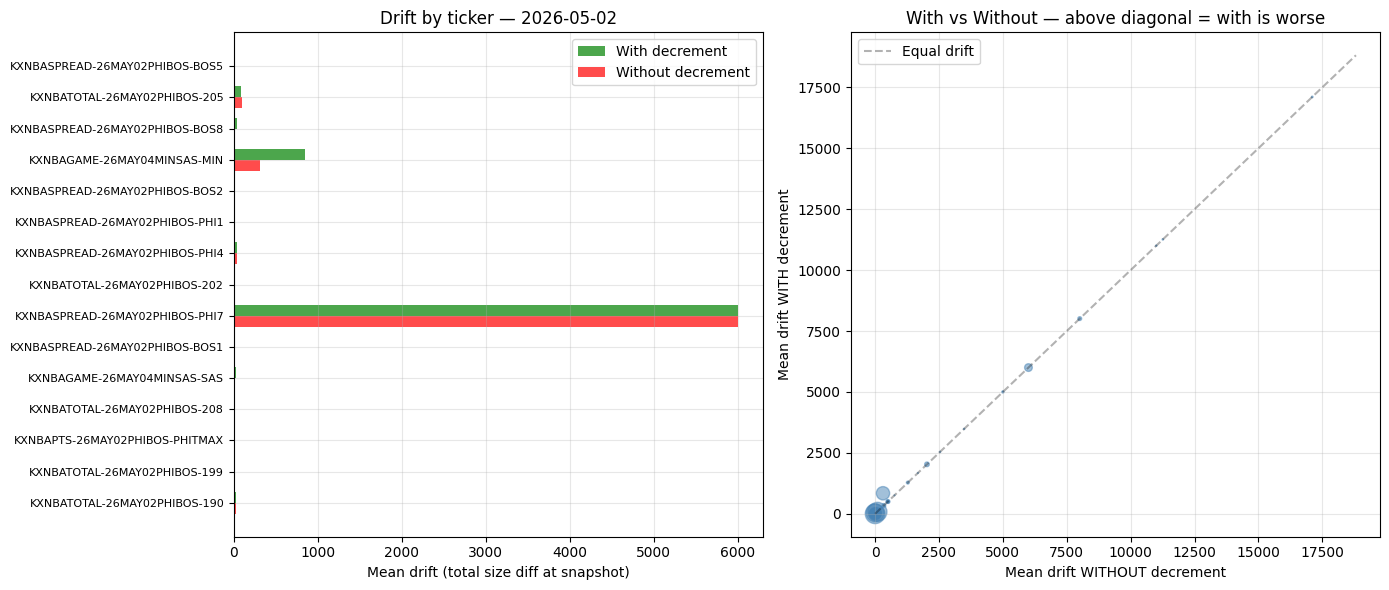

In [13]:
import matplotlib.pyplot as plt

if summary_rows2:
    summary2 = pd.DataFrame(summary_rows2).sort_values("n_trades", ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Bar chart: mean drift with vs without for top tickers
    top_n = min(15, len(summary2))
    top = summary2.head(top_n)
    x = range(top_n)
    w = 0.35
    axes[0].barh([i - w/2 for i in x], top["mean_drift_with"], w, color="green", alpha=0.7, label="With decrement")
    axes[0].barh([i + w/2 for i in x], top["mean_drift_without"], w, color="red", alpha=0.7, label="Without decrement")
    axes[0].set_yticks(x)
    axes[0].set_yticklabels([t[:30] for t in top["ticker"]], fontsize=8)
    axes[0].set_xlabel("Mean drift (total size diff at snapshot)")
    axes[0].set_title(f"Drift by ticker — {DATE2}")
    axes[0].legend()
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Scatter: with vs without
    axes[1].scatter(summary2["mean_drift_without"], summary2["mean_drift_with"], 
                    s=summary2["n_trades"] / summary2["n_trades"].max() * 200,
                    alpha=0.5, color="steelblue")
    max_val = max(summary2["mean_drift_with"].max(), summary2["mean_drift_without"].max()) * 1.1
    axes[1].plot([0, max_val], [0, max_val], "k--", alpha=0.3, label="Equal drift")
    axes[1].set_xlabel("Mean drift WITHOUT decrement")
    axes[1].set_ylabel("Mean drift WITH decrement")
    axes[1].set_title("With vs Without — above diagonal = with is worse")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot — run Step 6-7 first.")

## Findings so far

**Steps 3-4 strongly suggest fills ARE in deltas:**
- 99.7% of trades have a matching negative delta at the exact consumed price/side within ±10ms
- 99.6% match on exact fill size within ±1s
- This is essentially perfect correlation — the 0.3-0.4% misses are likely timing edge cases

**If confirmed, our pipeline is DOUBLE-COUNTING:**
- `KalshiTransform` manually decrements the consumed side on every trade (lines 110-117)
- But the `orderbook_delta` channel is ALSO sending a negative delta for the same fill
- This means we're subtracting the fill size twice, causing phantom negative sizes

**Still needed to fully confirm:**
- Step 5/8 replay test against snapshot ground truth (blocked by lack of re-snapshots on 4/22)
- Try a newer date (5/2 or 5/3) that has periodic re-snapshots
- If "without decrement" matches snapshots better than "with decrement", it's confirmed

**What the original "0% correlation" finding likely got wrong:**
- The previous test may have used seq-based matching (which doesn't work — different sids)
- Or it may have looked at the wrong side/price (not converting yes_price → consumed NO price)